In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
import random
import os
import tensorflow as tf

# 设置随机种子以确保结果可复现
SEED = 120
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# 配置TensorFlow确定性操作
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 所有库导入完成")
print(f"✓ 随机种子已设置为: {SEED}")

✓ 所有库导入完成
✓ 随机种子已设置为: 120


## 第一步：数据加载与时间戳解析

In [38]:
# 读取数据
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ 成功读取数据，形状：{df.shape}")
except Exception as e:
    raise RuntimeError(f"读取失败：{e}")

# 显示前几行
print(f"\n数据前 5 行：")
print(df.head())

# 确定列
time_col = df.columns[0]  # 第一列是时间戳
target_col = df.columns[-1]  # 最后一列是目标（CO2 容量）

print(f"\n列角色定义：")
print(f"  • 时间列：{time_col}")
print(f"  • 目标列：{target_col}")
print(f"  • 数据频率：1 分钟")
print(f"  • 总记录数：{len(df)}")

✓ 成功读取数据，形状：(7200, 59)

数据前 5 行：
                 Date      PI-2       TI-2         FI-2      PI-3       TI-3  \
0 2020-01-20 00:00:00 -0.053126  34.736652  1543.938721  0.052434  45.023132   
1 2020-01-20 00:01:00 -0.053289  34.732132  1541.767578  0.052564  45.045799   
2 2020-01-20 00:02:00 -0.053386  34.761639  1545.614746  0.052390  45.088932   
3 2020-01-20 00:03:00 -0.053370  34.731682  1544.225952  0.052236  45.071358   
4 2020-01-20 00:04:00 -0.053144  34.718353  1540.848267  0.052370  45.036755   

       O2-3      TI-32      TI-33      TI-34  ...        FI-16      TI-16  \
0  5.170577  37.777477  50.215652  61.217957  ...  9634.049805  34.619560   
1  5.139907  37.836792  50.203251  61.241829  ...  9661.376953  34.598999   
2  5.078373  37.840168  50.180534  61.217957  ...  9662.280273  34.551292   
3  4.915955  37.849812  50.215652  61.322845  ...  9656.855469  34.583843   
4  5.042109  37.914433  50.229359  61.233147  ...  9641.303711  34.584705   

         FI-151     TI-

## 第二步：选择特征并时间顺序分割

In [39]:
# 选定的 11 个特征（来自相关性分析）
selected_features = ['TI-34', 'TI-33', 'FI-30', 'FI-38', 'TI-4', 'TI-19', 'TI-12', 'TI-22', 'TI-24', 'TI-28', 'Level Reboiler']

# 验证特征是否存在
missing_features = [f for f in selected_features if f not in df.columns]
if missing_features:
    print(f"⚠ 警告：以下特征不存在：{missing_features}")
    print(f"实际列名：{list(df.columns)}")
    selected_features = [f for f in selected_features if f in df.columns]
    print(f"使用实际存在的特征：{selected_features}")

print(f"\n使用的特征（共 {len(selected_features)} 个）：")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# 提取特征和目标
X = df[selected_features].copy()
y = df[target_col].copy()

# 保存时间列用于可视化
time_series = pd.to_datetime(df[time_col])

# 处理缺失值（用中位数填充）
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

print(f"\n目标变量统计：")
print(f"  • 最小值：{y.min():.6f}")
print(f"  • 最大值：{y.max():.6f}")
print(f"  • 平均值：{y.mean():.6f}")
print(f"  • 标准差：{y.std():.6f}")

# 时间顺序分割：前 80% 训练，后 20% 测试
split_idx = int(len(df) * 0.8)

X_train_raw = X.iloc[:split_idx].reset_index(drop=True)
X_test_raw = X.iloc[split_idx:].reset_index(drop=True)
y_train_raw = y.iloc[:split_idx].reset_index(drop=True)
y_test_raw = y.iloc[split_idx:].reset_index(drop=True)
time_train = time_series.iloc[:split_idx].reset_index(drop=True)
time_test = time_series.iloc[split_idx:].reset_index(drop=True)

print(f"\n时间顺序分割结果：")
print(f"  • 训练数据：{len(X_train_raw)} 条（前 80%）")
print(f"  • 测试数据：{len(X_test_raw)} 条（后 20%）")
print(f"  • 训练集时间范围：{time_train.min()} 至 {time_train.max()}")
print(f"  • 测试集时间范围：{time_test.min()} 至 {time_test.max()}")


使用的特征（共 11 个）：
  1. TI-34
  2. TI-33
  3. FI-30
  4. FI-38
  5. TI-4
  6. TI-19
  7. TI-12
  8. TI-22
  9. TI-24
  10. TI-28
  11. Level Reboiler

目标变量统计：
  • 最小值：0.582062
  • 最大值：0.948009
  • 平均值：0.864631
  • 标准差：0.045872

时间顺序分割结果：
  • 训练数据：5760 条（前 80%）
  • 测试数据：1440 条（后 20%）
  • 训练集时间范围：2020-01-20 00:00:00 至 2020-01-23 23:59:00
  • 测试集时间范围：2020-01-24 00:00:00 至 2020-01-24 23:59:00


## 第三步：特征标准化（用训练集统计量）

In [40]:
# 在训练集上计算均值和标准差
scaler = StandardScaler()
scaler.fit(X_train_raw)  # 只在训练集上 fit

# 用训练集的统计量标准化训练集和测试集
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 转换为 DataFrame 保留列名
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features)

print("✓ 特征标准化完成")
print(f"\n训练集特征统计（标准化后）：")
print(f"  • 均值：{X_train_scaled.mean().values}")
print(f"  • 方差：{X_train_scaled.var().values}")
print(f"\n测试集中某些样本可能超出 [-1, 1] 范围，这是正常的")

✓ 特征标准化完成

训练集特征统计（标准化后）：
  • 均值：[ 3.55271368e-16 -1.97372982e-16  2.36847579e-16  9.86864911e-16
  7.89491929e-16  1.81583144e-15 -5.52644350e-16 -7.10542736e-16
  3.55271368e-15 -2.94085743e-15 -8.88178420e-15]
  • 方差：[1.00017364 1.00017364 1.00017364 1.00017364 1.00017364 1.00017364
 1.00017364 1.00017364 1.00017364 1.00017364 1.00017364]

测试集中某些样本可能超出 [-1, 1] 范围，这是正常的


## 第四步：构造滑动窗口数据

**规则：** 用前 10 个时间步（10 分钟）的特征值作为输入，预测下一个时间步（第 11 分钟）的目标值。

In [41]:
def create_sliding_windows(X, y, window_size=10):
    """
    创建滑动窗口数据
    
    参数：
      X: 特征数据 (n_samples, n_features)
      y: 目标数据 (n_samples,)
      window_size: 窗口大小（默认 10）
    
    返回：
      X_windows: 窗口化特征 (n_windows, window_size * n_features)
      y_windows: 窗口化目标 (n_windows,)
    """
    X_windows = []
    y_windows = []
    
    for i in range(len(X) - window_size):
        # 取第 i 到 i+window_size-1 的特征，展平为一行
        window = X.iloc[i:i+window_size].values.flatten()
        X_windows.append(window)
        
        # 目标是第 i+window_size 时刻的值
        y_windows.append(y.iloc[i+window_size])
    
    return np.array(X_windows), np.array(y_windows)

# 构造训练窗口
X_train_windows, y_train_windows = create_sliding_windows(X_train_scaled, y_train_raw, window_size=10)

# 构造测试窗口
X_test_windows, y_test_windows = create_sliding_windows(X_test_scaled, y_test_raw, window_size=10)

print(f"✓ 滑动窗口构造完成")
print(f"\n训练数据：")
print(f"  • 样本数：{X_train_windows.shape[0]}")
print(f"  • 特征维度：{X_train_windows.shape[1]}（10 分钟 × {len(selected_features)} 特征）")
print(f"\n测试数据：")
print(f"  • 样本数：{X_test_windows.shape[0]}")
print(f"  • 特征维度：{X_test_windows.shape[1]}")

print(f"\n样本示例（训练集第 1 个样本）：")
print(f"  输入形状：{X_train_windows[0].shape}")
print(f"  输入（前 20 个值）：{X_train_windows[0][:20]}")
print(f"  目标值：{y_train_windows[0]}")

✓ 滑动窗口构造完成

训练数据：
  • 样本数：5750
  • 特征维度：110（10 分钟 × 11 特征）

测试数据：
  • 样本数：1430
  • 特征维度：110

样本示例（训练集第 1 个样本）：
  输入形状：(110,)
  输入（前 20 个值）：[-0.76269694 -0.77526843 -0.01724584 -0.18599427 -0.47915401 -0.50228309
 -0.52739672 -0.50061837 -0.84930908 -0.04796601  0.84070529 -0.75259289
 -0.78193782 -0.18912994 -0.1312676  -0.48068931 -0.52414832 -0.52561594
 -0.5051719  -0.84003087]
  目标值：0.846168723536747


## 第五步：重塑数据格式用于LSTM

In [42]:
# 将展平的窗口数据重塑为 (样本数, 时间步, 特征数)
X_train_lstm = X_train_windows.reshape((X_train_windows.shape[0], 10, 11))
X_test_lstm = X_test_windows.reshape((X_test_windows.shape[0], 10, 11))

print(f"✓ 数据重塑完成")
print(f"\n重塑后的数据形状：")
print(f"  • 训练数据：{X_train_lstm.shape}（样本数, 时间步, 特征数）")
print(f"  • 测试数据：{X_test_lstm.shape}（样本数, 时间步, 特征数）")
print(f"  • 目标变量：{y_train_windows.shape}")

## 第六步：LSTM模型构建与训练

print("\n正在构建LSTM模型...")
model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(10, 11)),
    Dropout(0.3),
    LSTM(64, activation='relu'),
    Dropout(0.3),
    Dense(1)  # 输出层：预测单个值
])

# 编译模型
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(f"✓ 模型构建完成")
print(f"\n模型架构：")
model.summary()

print(f"\n模型配置：")
print(f"  • 模型类型：LSTM神经网络")
print(f"  • 隐藏层1：LSTM 64个神经元 + Dropout(0.4)")
print(f"  • 隐藏层2：LSTM 64个神经元 + Dropout(0.4)")
print(f"  • 输出层：Dense 1个神经元")
print(f"  • 优化器：Adam(learning_rate=0.001)")
print(f"  • 损失函数：MSE(均方误差)")

# 定义早停回调
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

print(f"\n正在训练模型...")
print(f"  • 批量大小：32")
print(f"  • Epoch数量：150（配合Early Stopping）")
print(f"  • 验证集比例：20%")

# 训练模型
history = model.fit(
    X_train_lstm, y_train_windows,
    batch_size=32,
    epochs=150,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\n✓ 模型训练完成")
print(f"  • 实际训练 Epoch 数：{len(history.history['loss'])}")
print(f"  • 最终训练损失：{history.history['loss'][-1]:.6f}")
print(f"  • 最终验证损失：{history.history['val_loss'][-1]:.6f}")

# 在训练集上的性能
print(f"\n计算训练集性能...")
y_train_pred = model.predict(X_train_lstm, verbose=0)
y_train_pred = y_train_pred.flatten()

train_r2 = r2_score(y_train_windows, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_windows, y_train_pred))
train_mae = mean_absolute_error(y_train_windows, y_train_pred)

print(f"\n训练集性能：")
print(f"  • R²：{train_r2:.4f}")
print(f"  • RMSE：{train_rmse:.6f}")
print(f"  • MAE：{train_mae:.6f}")

✓ 数据重塑完成

重塑后的数据形状：
  • 训练数据：(5750, 10, 11)（样本数, 时间步, 特征数）
  • 测试数据：(1430, 10, 11)（样本数, 时间步, 特征数）
  • 目标变量：(5750,)

正在构建LSTM模型...
✓ 模型构建完成

模型架构：
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 10, 64)            19456     
                                                                 
 dropout_6 (Dropout)         (None, 10, 64)            0         
                                                                 
 lstm_7 (LSTM)               (None, 64)                33024     
                                                                 
 dropout_7 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 52,545
Trainable params: 5

## 第七步：模型性能评估（测试集）

In [43]:
# 在测试集上预测
y_test_pred = model.predict(X_test_lstm, verbose=0)
y_test_pred = y_test_pred.flatten()

# 计算性能指标
test_r2 = r2_score(y_test_windows, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_windows, y_test_pred))
test_mae = mean_absolute_error(y_test_windows, y_test_pred)

# 计算残差
residuals = y_test_windows - y_test_pred
residuals_std = np.std(residuals)
residuals_mean = np.mean(residuals)



# 计算MAPE（平均绝对百分比误差）
test_mape = np.mean(np.abs((y_test_windows - y_test_pred) / y_test_windows)) * 100

# 计算WQL（加权分位数损失）- Weighted Quantile Loss
def weighted_quantile_loss(y_true, y_pred, quantiles=[0.1, 0.5, 0.9]):
    """
    计算加权分位数损失（WQL）
    用于评估预测的不确定性和在不同分位数下的表现
    """
    losses = []
    for q in quantiles:
        errors = y_true - y_pred
        loss = np.maximum(q * errors, (q - 1) * errors)
        losses.append(np.mean(loss))
    return np.mean(losses)

test_wql = weighted_quantile_loss(y_test_windows, y_test_pred)

print("="*80)
print("测试集性能评估结果")
print("="*80)

print(f"\n【预测精度指标】")
print(f"  • R² 分数：{test_r2:.4f}")
print(f"    └─ 说明：模型解释了 {test_r2*100:.2f}% 的目标变量方差")
print(f"  • RMSE（均方根误差）：{test_rmse:.6f}")
print(f"    └─ 说明：平均预测偏差")
print(f"  • MAE（平均绝对误差）：{test_mae:.6f}")
print(f"    └─ 说明：平均绝对偏差")
print(f"  • MAPE（平均绝对百分比误差）：{test_mape:.2f}%")
print(f"    └─ 说明：预测误差的百分比表示")
print(f"  • WQL（加权分位数损失）：{test_wql:.6f}")
print(f"    └─ 说明：在多个分位数(0.1, 0.5, 0.9)下的平均损失")

print(f"\n【预测值与实际值统计】")
print(f"  实际值：")
print(f"    • 最小：{y_test_windows.min():.6f}，最大：{y_test_windows.max():.6f}")
print(f"    • 均值：{y_test_windows.mean():.6f}，标准差：{y_test_windows.std():.6f}")
print(f"  预测值：")
print(f"    • 最小：{y_test_pred.min():.6f}，最大：{y_test_pred.max():.6f}")
print(f"    • 均值：{y_test_pred.mean():.6f}，标准差：{y_test_pred.std():.6f}")

print(f"\n【残差分析】")
print(f"  • 残差均值：{residuals_mean:.6f}（接近 0 为好）")
print(f"  • 残差标准差：{residuals_std:.6f}")
print(f"  • 残差最小值：{residuals.min():.6f}")
print(f"  • 残差最大值：{residuals.max():.6f}")

测试集性能评估结果

【预测精度指标】
  • R² 分数：0.9251
    └─ 说明：模型解释了 92.51% 的目标变量方差
  • RMSE（均方根误差）：0.011381
    └─ 说明：平均预测偏差
  • MAE（平均绝对误差）：0.008266
    └─ 说明：平均绝对偏差
  • MAPE（平均绝对百分比误差）：0.99%
    └─ 说明：预测误差的百分比表示
  • WQL（加权分位数损失）：0.004133
    └─ 说明：在多个分位数(0.1, 0.5, 0.9)下的平均损失

【预测值与实际值统计】
  实际值：
    • 最小：0.735384，最大：0.914714
    • 均值：0.852431，标准差：0.041595
  预测值：
    • 最小：0.750841，最大：0.894184
    • 均值：0.856837，标准差：0.036589

【残差分析】
  • 残差均值：-0.004406（接近 0 为好）
  • 残差标准差：0.010493
  • 残差最小值：-0.083140
  • 残差最大值：0.046386


## 第八步：结果可视化

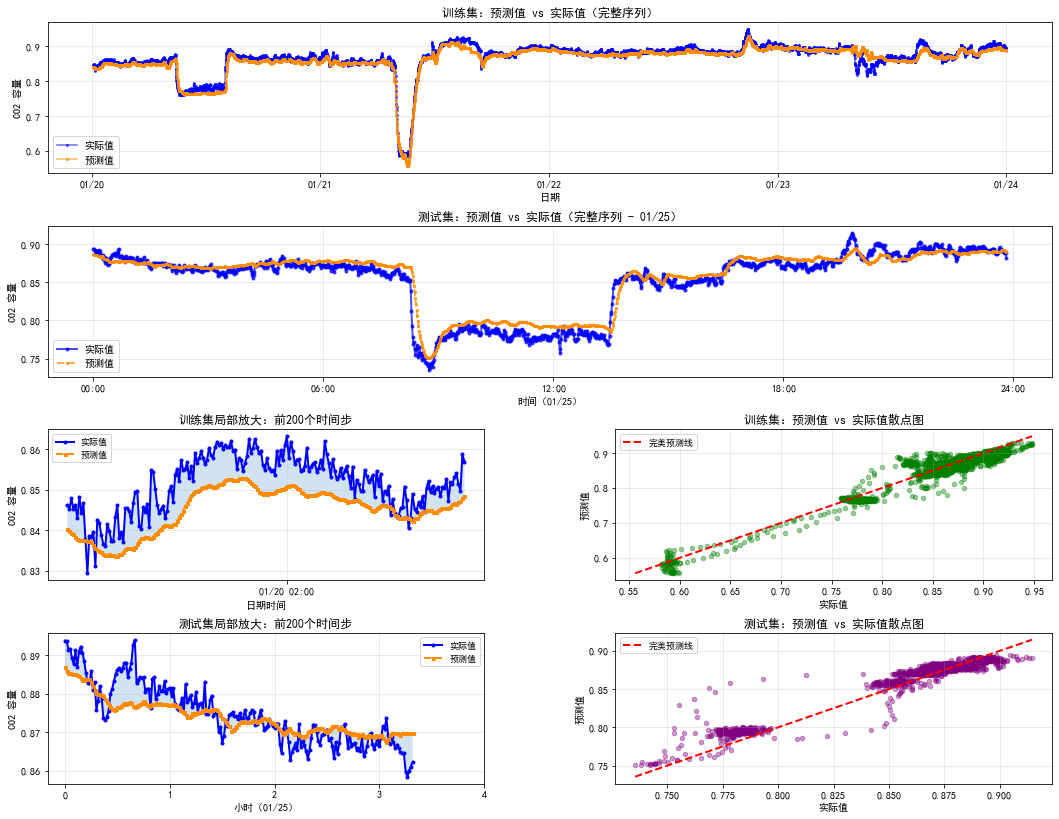

✓ 可视化图表已保存为 'time_series_prediction_results.png'
  • 训练集时间范围：01/20 至 01/23
  • 测试集时间范围：01/24 00:10 至 01/24 23:59 (01/25当天)


In [59]:
# 准备时间序列数据
# 从原始数据中获取实际的时间信息（从第10个时间步开始，因为窗口大小为10）
train_dates_original = time_train.iloc[10:10+len(y_train_windows)]
test_dates_original = time_test.iloc[10:10+len(y_test_windows)]

# 创建大图表 - 包含训练集和测试集
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.3)

# ==================== 训练集可视化 ====================
# 图 1：训练集时序预测对比（完整序列）
ax1 = fig.add_subplot(gs[0, :])
# 直接使用 pandas datetime 作为横坐标
ax1.plot(train_dates_original, y_train_windows, 'o-', label='实际值', linewidth=1.5, markersize=2, alpha=0.6, color='blue')
ax1.plot(train_dates_original, y_train_pred, 's-', label='预测值', linewidth=1.5, markersize=2, alpha=0.6, color='darkorange')
ax1.set_xlabel('日期', fontweight='bold')
ax1.set_ylabel('CO2 容量', fontweight='bold')
ax1.set_title('训练集：预测值 vs 实际值（完整序列）', fontweight='bold', fontsize=12)
# 使用 matplotlib 日期格式化
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax1.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0, ha='center')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# 图 2：测试集时序预测对比（完整序列）
ax4 = fig.add_subplot(gs[1, :])
# 将测试集时间转换为小时（从0开始）
test_hours = np.arange(len(y_test_windows)) / 60  # 每分钟一个数据点，转换为小时
ax4.plot(test_hours, y_test_windows, 'o-', label='实际值', linewidth=2, markersize=3, alpha=0.7, color='blue')
ax4.plot(test_hours, y_test_pred, 's--', label='预测值', linewidth=2, markersize=2.5, alpha=0.7, color='darkorange')
ax4.set_xlabel('时间（01/25）', fontweight='bold')
ax4.set_ylabel('CO2 容量', fontweight='bold')
ax4.set_title('测试集：预测值 vs 实际值（完整序列 - 01/25）', fontweight='bold', fontsize=12)
# 设置x轴刻度为6小时间隔，从0到24小时，格式为'00:00'
ax4.set_xticks(np.arange(0, max(test_hours)+1, 6))
ax4.set_xticklabels([f'{int(h):02d}:00' for h in np.arange(0, max(test_hours)+1, 6)])
ax4.legend(loc='best', fontsize=10)
ax4.grid(True, alpha=0.3)

# 图 3：训练集局部放大
ax2 = fig.add_subplot(gs[2, 0])
plot_range_train = slice(0, min(200, len(y_train_windows)))
train_local_dates = train_dates_original.iloc[plot_range_train]
ax2.plot(train_local_dates, y_train_windows[plot_range_train], 'o-', label='实际值', linewidth=2, markersize=3, color='blue')
ax2.plot(train_local_dates, y_train_pred[plot_range_train], 's--', label='预测值', linewidth=2, markersize=3, color='darkorange')
ax2.fill_between(train_local_dates, y_train_windows[plot_range_train], y_train_pred[plot_range_train], alpha=0.2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0, ha='center')
ax2.set_xlabel('日期时间', fontweight='bold')
ax2.set_ylabel('CO2 容量', fontweight='bold')
ax2.set_title('训练集局部放大：前200个时间步', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 图 4：训练集散点图
ax3 = fig.add_subplot(gs[2, 1])
ax3.scatter(y_train_windows, y_train_pred, alpha=0.4, s=20, color='green')
min_val_train = min(y_train_windows.min(), y_train_pred.min())
max_val_train = max(y_train_windows.max(), y_train_pred.max())
ax3.plot([min_val_train, max_val_train], [min_val_train, max_val_train], 'r--', linewidth=2, label='完美预测线')
ax3.set_xlabel('实际值', fontweight='bold')
ax3.set_ylabel('预测值', fontweight='bold')
ax3.set_title('训练集：预测值 vs 实际值散点图', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 图 5：测试集局部放大
ax5 = fig.add_subplot(gs[3, 0])
plot_range_test = slice(0, min(200, len(y_test_windows)))
test_local_hours = test_hours[plot_range_test]
ax5.plot(test_local_hours, y_test_windows[plot_range_test], 'o-', label='实际值', linewidth=2, markersize=3, color='blue')
ax5.plot(test_local_hours, y_test_pred[plot_range_test], 's--', label='预测值', linewidth=2, markersize=3, color='darkorange')
ax5.fill_between(test_local_hours, y_test_windows[plot_range_test], y_test_pred[plot_range_test], alpha=0.2)
ax5.set_xticks(np.arange(0, max(test_local_hours)+1, 1))  # 每小时一个刻度
ax5.set_xlabel('小时（01/25）', fontweight='bold')
ax5.set_ylabel('CO2 容量', fontweight='bold')
ax5.set_title('测试集局部放大：前200个时间步', fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 图 6：测试集散点图
ax6 = fig.add_subplot(gs[3, 1])
ax6.scatter(y_test_windows, y_test_pred, alpha=0.4, s=20, color='purple')
min_val_test = min(y_test_windows.min(), y_test_pred.min())
max_val_test = max(y_test_windows.max(), y_test_pred.max())
ax6.plot([min_val_test, max_val_test], [min_val_test, max_val_test], 'r--', linewidth=2, label='完美预测线')
ax6.set_xlabel('实际值', fontweight='bold')
ax6.set_ylabel('预测值', fontweight='bold')
ax6.set_title('测试集：预测值 vs 实际值散点图', fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

plt.savefig('time_series_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 可视化图表已保存为 'time_series_prediction_results.png'")

print(f"  • 训练集时间范围：{train_dates_original.iloc[0].strftime('%m/%d')} 至 {train_dates_original.iloc[-1].strftime('%m/%d')}")
print(f"  • 测试集时间范围：{test_dates_original.iloc[0].strftime('%m/%d %H:%M')} 至 {test_dates_original.iloc[-1].strftime('%m/%d %H:%M')} (01/25当天)")

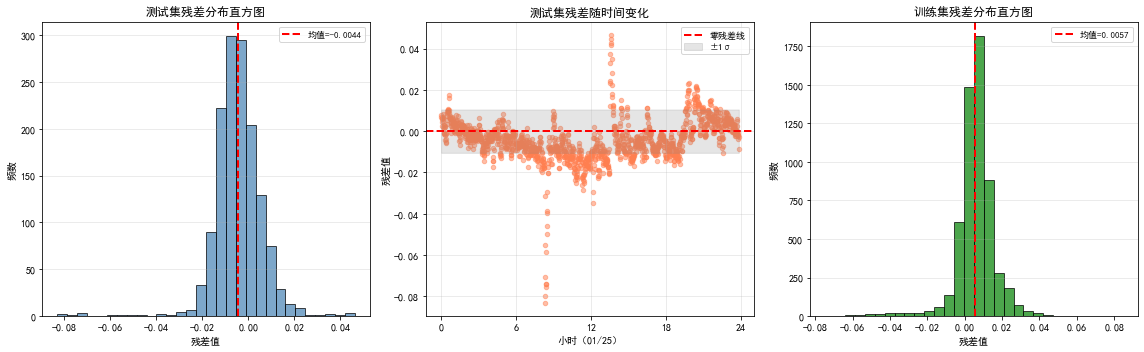

✓ 残差分析图表已保存为 'residual_analysis.png'


In [60]:
# 额外的残差分析图
fig2 = plt.figure(figsize=(16, 5))

# 图 1：测试集残差分布
ax1 = fig2.add_subplot(1, 3, 1)
ax1.hist(residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(residuals_mean, color='red', linestyle='--', linewidth=2, label=f'均值={residuals_mean:.4f}')
ax1.set_xlabel('残差值', fontweight='bold')
ax1.set_ylabel('频数', fontweight='bold')
ax1.set_title('测试集残差分布直方图', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# 图 2：测试集残差随时间变化
ax2 = fig2.add_subplot(1, 3, 2)
# 使用小时作为横坐标
ax2.scatter(test_hours, residuals, alpha=0.5, s=20, color='coral')
ax2.axhline(0, color='red', linestyle='--', linewidth=2, label='零残差线')
ax2.fill_between(test_hours, -residuals_std, residuals_std, alpha=0.2, color='gray', label='±1σ')
ax2.set_xticks(np.arange(0, max(test_hours)+1, 6))  # 每6小时一个刻度
ax2.set_xlabel('小时（01/25）', fontweight='bold')
ax2.set_ylabel('残差值', fontweight='bold')
ax2.set_title('测试集残差随时间变化', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 图 3：训练集残差分布
ax3 = fig2.add_subplot(1, 3, 3)
train_residuals = y_train_windows - y_train_pred
train_residuals_mean = np.mean(train_residuals)
ax3.hist(train_residuals, bins=30, color='green', edgecolor='black', alpha=0.7)
ax3.axvline(train_residuals_mean, color='red', linestyle='--', linewidth=2, label=f'均值={train_residuals_mean:.4f}')
ax3.set_xlabel('残差值', fontweight='bold')
ax3.set_ylabel('频数', fontweight='bold')
ax3.set_title('训练集残差分布直方图', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 残差分析图表已保存为 'residual_analysis.png'")

## 第九步：训练过程可视化

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

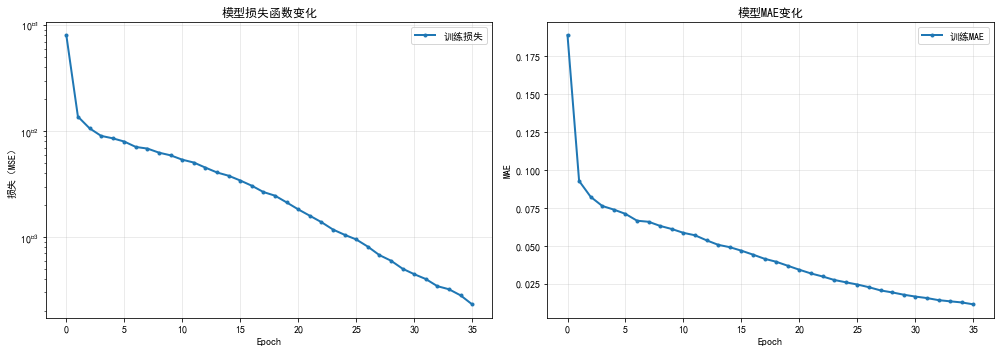

✓ 训练曲线已保存为 'training_history.png'

【训练过程汇总】
  • 总 Epoch 数：36
  • 初始训练损失：0.080377
  • 最终训练损失：0.000232
  • 损失下降比例：99.71%


In [61]:
# 训练历史可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图 1：损失函数变化
ax1 = axes[0]
ax1.plot(history.history['loss'], label='训练损失', linewidth=2, marker='o', markersize=3)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('损失（MSE）', fontweight='bold')
ax1.set_title('模型损失函数变化', fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# 图 2：MAE变化
ax2 = axes[1]
ax2.plot(history.history['mae'], label='训练MAE', linewidth=2, marker='o', markersize=3)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('MAE', fontweight='bold')
ax2.set_title('模型MAE变化', fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 训练曲线已保存为 'training_history.png'")

# 训练汇总
print("\n【训练过程汇总】")
print(f"  • 总 Epoch 数：{len(history.history['loss'])}")
print(f"  • 初始训练损失：{history.history['loss'][0]:.6f}")
print(f"  • 最终训练损失：{history.history['loss'][-1]:.6f}")
print(f"  • 损失下降比例：{(1 - history.history['loss'][-1] / history.history['loss'][0]) * 100:.2f}%")

## 第十步：结果汇总与保存

In [62]:
# 创建汇总报告
summary_report = f"""
{'='*80}
时序预测模型性能总结报告（LSTM神经网络）
{'='*80}

【数据配置】
  • 原始数据点数：{len(df)}
  • 采样频率：1 分钟/条
  • 时间跨度：约 {len(df)} 分钟
  • 选定特征数：{len(selected_features)}

【数据分割】
  • 训练集：{len(X_train_raw)} 条（前 80%）
  • 测试集：{len(X_test_raw)} 条（后 20%）
  • 训练窗口数：{len(X_train_windows)}（每个窗口 10 分钟）
  • 测试窗口数：{len(X_test_windows)}（每个窗口 10 分钟）

【模型配置】
  • 模型类型：LSTM神经网络
  • 输入形状：(样本数, 10时间步, 10特征)
  • 隐藏层1：LSTM 64个神经元 + Dropout(0.4) + return_sequences=True
  • 隐藏层2：LSTM 64个神经元 + Dropout(0.4)
  • 输出层：Dense 1个神经元
  • 优化器：Adam(learning_rate=0.001)
  • 损失函数：MSE(均方误差)
  • 预测任务：前 10 分钟 → 下 1 分钟

【训练配置】
  • 批量大小：32
  • Epoch 数量：150（配合Early Stopping）
  • 实际训练 Epoch：{len(history.history['loss'])}
  • Early Stopping：监控训练损失，耐心值=20
  • 数据打乱：否（保持时序完整性）

【性能指标】

  训练集：
    • R²：{train_r2:.4f}
    • RMSE：{train_rmse:.6f}
    • MAE：{train_mae:.6f}

  测试集：
    • R²：{test_r2:.4f}
    • RMSE：{test_rmse:.6f}
    • MAE：{test_mae:.6f}
    • MAPE：{test_mape:.2f}%
    • WQL：{test_wql:.6f}

【预测精度解释】
  • R² = {test_r2:.4f}：模型解释了测试集 {test_r2*100:.2f}% 的目标变量方差
  • RMSE = {test_rmse:.6f}：平均预测误差（在原始数据尺度上）
  • MAE = {test_mae:.6f}：平均绝对偏差
  • MAPE = {test_mape:.2f}%：平均绝对百分比误差
  • WQL = {test_wql:.6f}：加权分位数损失（评估不同分位数下的表现）

【残差分析】
  • 残差均值：{residuals_mean:.6f}（接近 0 表示预测无偏）
  • 残差标准差：{residuals_std:.6f}
  • 残差范围：[{residuals.min():.6f}, {residuals.max():.6f}]

【训练过程】
  • 初始训练损失：{history.history['loss'][0]:.6f}
  • 最终训练损失：{history.history['loss'][-1]:.6f}
  • 损失下降比例：{(1 - history.history['loss'][-1] / history.history['loss'][0]) * 100:.2f}%

{'='*80}
"""

print(summary_report)

# 保存报告
with open('time_series_prediction_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)
print("✓ 报告已保存为 'time_series_prediction_report.txt'")


时序预测模型性能总结报告（LSTM神经网络）

【数据配置】
  • 原始数据点数：7200
  • 采样频率：1 分钟/条
  • 时间跨度：约 7200 分钟
  • 选定特征数：11

【数据分割】
  • 训练集：5760 条（前 80%）
  • 测试集：1440 条（后 20%）
  • 训练窗口数：5750（每个窗口 10 分钟）
  • 测试窗口数：1430（每个窗口 10 分钟）

【模型配置】
  • 模型类型：LSTM神经网络
  • 输入形状：(样本数, 10时间步, 10特征)
  • 隐藏层1：LSTM 64个神经元 + Dropout(0.4) + return_sequences=True
  • 隐藏层2：LSTM 64个神经元 + Dropout(0.4)
  • 输出层：Dense 1个神经元
  • 优化器：Adam(learning_rate=0.001)
  • 损失函数：MSE(均方误差)
  • 预测任务：前 10 分钟 → 下 1 分钟

【训练配置】
  • 批量大小：32
  • Epoch 数量：150（配合Early Stopping）
  • 实际训练 Epoch：36
  • Early Stopping：监控训练损失，耐心值=20
  • 数据打乱：否（保持时序完整性）

【性能指标】

  训练集：
    • R²：0.9287
    • RMSE：0.012402
    • MAE：0.008945

  测试集：
    • R²：0.9251
    • RMSE：0.011381
    • MAE：0.008266
    • MAPE：0.99%
    • WQL：0.004133

【预测精度解释】
  • R² = 0.9251：模型解释了测试集 92.51% 的目标变量方差
  • RMSE = 0.011381：平均预测误差（在原始数据尺度上）
  • MAE = 0.008266：平均绝对偏差
  • MAPE = 0.99%：平均绝对百分比误差
  • WQL = 0.004133：加权分位数损失（评估不同分位数下的表现）

【残差分析】
  • 残差均值：-0.004406（接近 0 表示预测无偏）
  • 残差标准差：0.010493
  • 残差范围：[-0.0

In [63]:
# 保存预测结果为 CSV
results_df = pd.DataFrame({
    '时间步': np.arange(len(y_test_windows)),
    '实际值': y_test_windows,
    '预测值': y_test_pred,
    '残差': residuals,
    '绝对误差': np.abs(residuals),
    '相对误差(%)': np.abs(residuals) / np.abs(y_test_windows) * 100
})

results_df.to_csv('time_series_predictions.csv', index=False, encoding='utf-8-sig')
print("✓ 预测结果已保存为 'time_series_predictions.csv'")

# 保存性能指标汇总
metrics_summary = pd.DataFrame({
    '指标': ['R²', 'RMSE', 'MAE', 'MAPE(%)', 'WQL', '残差均值', '残差标准差'],
    '训练集': [train_r2, train_rmse, train_mae, np.nan, np.nan, np.nan, np.nan],
    '测试集': [test_r2, test_rmse, test_mae, test_mape, test_wql, residuals_mean, residuals_std]
})

metrics_summary.to_csv('performance_metrics.csv', index=False, encoding='utf-8-sig')
print("✓ 性能指标已保存为 'performance_metrics.csv'")

# 保存模型
model.save('lstm_model.h5')
print("✓ LSTM模型已保存为 'lstm_model.h5'")

print("\n" + "="*80)
print("✅ 所有文件生成完成！")
print("="*80)
print("\n生成的文件：")
print("  1. time_series_prediction_results.png - 预测结果可视化（5 个子图）")
print("  2. training_history.png - 训练过程可视化（损失和MAE曲线）")
print("  3. time_series_prediction_report.txt - 性能汇总报告")
print("  4. time_series_predictions.csv - 详细预测结果")
print("  5. performance_metrics.csv - 性能指标汇总")
print("  6. lstm_model.h5 - 训练好的LSTM模型")

✓ 预测结果已保存为 'time_series_predictions.csv'
✓ 性能指标已保存为 'performance_metrics.csv'
✓ LSTM模型已保存为 'lstm_model.h5'

✅ 所有文件生成完成！

生成的文件：
  1. time_series_prediction_results.png - 预测结果可视化（5 个子图）
  2. training_history.png - 训练过程可视化（损失和MAE曲线）
  3. time_series_prediction_report.txt - 性能汇总报告
  4. time_series_predictions.csv - 详细预测结果
  5. performance_metrics.csv - 性能指标汇总
  6. lstm_model.h5 - 训练好的LSTM模型
